## Исследование удойности коров и вкусовых качеств молока для принятия управленческих решений 

**Цель исследования:** 
Необходимо провести анализ ряда параметров действующего стада коров заказчика для выявления зависимостей удойности и вкусовых качеств. Для этого необходимо построить регрессионную и логистическую модели, определить порог отнесения к классам. На основе построенных моделей будет сделаны предсказания о возможной удойности и вкусе молока коров предлагаемых к приобретению от ассоциации пастбищ «ЭкоФерма». По прогнозу необходимо отобрать коров, удой которых будет больше 6000 кг/год и молоко будет вкуным. 

**Задачи исследования:**
 1) Загрузка и изучение данных
 
 2) Предобработка: поиск дубликав, пропусков, изменение типов данных
 
 3) Исследовательский анализ данных: статистический анализ данных, визуализация, поиск выбросов
 
 4) Корреляционных анализ данных: изучение взаимосвязей между признаками, их визуализация
 
 5) Построение модели линейной регрессии с целевым признаком "Удой"
 
 6) Построение модели логистической регрессии с целевым признаком "Вкус молока"
 
 7) Выводы

## Загрузка данных

In [1]:
!pip install phik -q

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression 
from sklearn.preprocessing import StandardScaler, OneHotEncoder 
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    accuracy_score,
    confusion_matrix,
    precision_score, recall_score
)
import phik

### Датасет данных о стаде

In [3]:
df = pd.read_csv('/datasets/ferma_main.csv', sep=';', decimal = ',') #читаем файл csv
display(df.head()) #выводим первые 5 строк

,id,"Удой, кг",ЭКЕ (Энергетическая кормовая единица),"Сырой протеин, г",СПО (Сахаро-протеиновое соотношение),Порода,Тип пастбища,порода папы_быка,"Жирность,%","Белок,%",Вкус молока,Возраст
0,1,5863,14.2,1743,0.890,Вис Бик Айдиал,Равнинное,Айдиал,3.58,3.076,вкусно,более_2_лет
1,2,5529,12.8,2138,0.890,Вис Бик Айдиал,Равнинные,Соверин,3.54,3.079,вкусно,менее_2_лет
2,3,5810,14.0,1854,0.885,РефлешнСоверинг,Холмистое,Соверин,3.59,3.074,не вкусно,более_2_лет
3,4,5895,12.4,2012,0.885,РефлешнСоверинг,Холмистое,Айдиал,3.40,3.075,не вкусно,более_2_лет
4,5,5302,12.8,1675,0.885,Вис Бик Айдиал,Равнинные,Соверин,3.73,3.073,вкусно,менее_2_лет


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 634 entries, 0 to 633
Data columns (total 12 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     634 non-null    int64  
 1   Удой, кг                               634 non-null    int64  
 2   ЭКЕ (Энергетическая кормовая единица)  634 non-null    float64
 3   Сырой протеин, г                       634 non-null    int64  
 4   СПО (Сахаро-протеиновое соотношение)   634 non-null    float64
 5   Порода                                 634 non-null    object 
 6   Тип пастбища                           634 non-null    object 
 7   порода папы_быка                       634 non-null    object 
 8   Жирность,%                             634 non-null    float64
 9   Белок,%                                634 non-null    float64
 10  Вкус молока                            634 non-null    object 
 11  Возрас

In [5]:
#переименовываем столбцы латиницей, переводим в нижний регистр и корректный стиль через нижнее подчеркивание
df_main = df.rename(columns = {'Удой, кг':'yield',
                          'ЭКЕ (Энергетическая кормовая единица)':'energy_feed_unit',
                          'Сырой протеин, г': 'crude_protein',
                          'СПО (Сахаро-протеиновое соотношение)':'sugar_protein_ratio',
                          'Порода':'breed',
                          'Тип пастбища':'pasture_type',
                          'порода папы_быка':'dad_breed',
                          'Жирность,%':'fat_content',
                          'Белок,%':'protein',
                          'Вкус молока':'taste',
                          'Возраст':'age'
                              }
                   ).copy()
display(df_main.columns)

Index(['id', 'yield', 'energy_feed_unit', 'crude_protein',
       'sugar_protein_ratio', 'breed', 'pasture_type', 'dad_breed',
       'fat_content', 'protein', 'taste', 'age'],
      dtype='object')

### Датасет данных клички папы каждой коровы в стаде фермера

In [6]:
df_dad = pd.read_csv('/datasets/ferma_dad.csv', sep=';') #читаем файл csv
display(df_dad.head()) #выводим первые 5 строк

,id,Имя Папы
0,1,Буйный
1,2,Соловчик
2,3,Барин
3,4,Буйный
4,5,Барин


In [7]:
df_dad.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 629 entries, 0 to 628
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        629 non-null    int64 
 1   Имя Папы  629 non-null    object
dtypes: int64(1), object(1)
memory usage: 10.0+ KB


In [8]:
#переименовываем столбцы латиницей, переводим в нижний регистр и корректный стиль через нижнее подчеркивание
df_dad = df_dad.rename(columns = {'Имя Папы':'dad_name'})
display(df_dad.columns)

Index(['id', 'dad_name'], dtype='object')

### Датасет данных о коровах «ЭкоФермы»

In [9]:
df_buy = pd.read_csv('/datasets/cow_buy.csv', sep=';', decimal = ',') #читаем файл csv
display(df_buy.head()) #выводим первые 5 строк

,Порода,Тип пастбища,порода папы_быка,Имя_папы,"Текущая_жирность,%","Текущий_уровень_белок,%",Возраст
0,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,3.58,3.076,более_2_лет
1,Вис Бик Айдиал,равнинное,Соверин,Буйный,3.54,3.081,менее_2_лет
2,РефлешнСоверинг,равнинное,Соверин,Барин,3.59,3.074,более_2_лет
3,РефлешнСоверинг,холмистое,Айдиал,Буйный,3.40,3.061,более_2_лет
4,РефлешнСоверинг,равнинное,Айдиал,Буйный,3.64,3.074,более_2_лет


In [10]:
df_buy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Порода                   20 non-null     object 
 1   Тип пастбища             20 non-null     object 
 2   порода папы_быка         20 non-null     object 
 3   Имя_папы                 20 non-null     object 
 4   Текущая_жирность,%       20 non-null     float64
 5   Текущий_уровень_белок,%  20 non-null     float64
 6   Возраст                  20 non-null     object 
dtypes: float64(2), object(5)
memory usage: 1.2+ KB


In [11]:
#переименовываем столбцы латиницей, переводим в нижний регистр и корректный стиль через нижнее подчеркивание
df_buy = df_buy.rename(columns = {'Порода':'breed',
                                  'Тип пастбища':'pasture_type',
                                  'порода папы_быка':'dad_breed',
                                  'Имя_папы':'dad_name',
                                  'Текущая_жирность,%':'fat_content_current',
                                  'Текущий_уровень_белок,%':'protein_current',
                                  'Возраст':'age'
                                  }
                      )
display(df_buy.columns)

Index(['breed', 'pasture_type', 'dad_breed', 'dad_name', 'fat_content_current',
       'protein_current', 'age'],
      dtype='object')

**Вывод:** 
1) В основнм датасете с данными о стаде коров изменены наименования столбцов. Пропуски не найдены. Предобработка в части типов данных не требуется.

2) Аналогичная обработка требуется и для датасета с данными о коровах Экофермы.

3) Данные о кличках папы каждой коровы в стаде фермера менять не требуется.

##  Предобработка данных

#### Проверка неявлных дубликатов 

Проведем проверку уникальных значений таблицы на наличие неявных дубликатов и исправим их.

In [12]:
df_main['breed'].unique()

array(['Вис Бик Айдиал', 'РефлешнСоверинг'], dtype=object)

In [13]:
print(df_buy['pasture_type'].unique())
df_main['pasture_type'].unique()

['холмистое' 'равнинное']


array(['Равнинное', 'Равнинные', 'Холмистое'], dtype=object)

In [14]:
df_main.replace('Равнинные', 'равнинное', regex=True, inplace=True)
df_main.replace('Равнинное', 'равнинное', regex=True, inplace=True)
df_main.replace('Холмистое', 'холмистое', regex=True, inplace=True)

In [15]:
print(df_buy['dad_breed'].unique())
df_main['dad_breed'].unique()

['Айдиал' 'Соверин']


array(['Айдиал', 'Соверин', 'Айдиалл'], dtype=object)

In [16]:
df_main.replace('Айдиалл', 'Айдиал', regex=True, inplace=True)

In [17]:
df_main['taste'].unique()

array(['вкусно', 'не вкусно'], dtype=object)

In [18]:
print(df_buy['age'].unique())
df_main['age'].unique()

['более_2_лет' 'менее_2_лет']


array(['более_2_лет', 'менее_2_лет'], dtype=object)

#### Проверка дубликатов

In [19]:
df_main.duplicated().sum()

5

Найдено 5 полных дубликатов. Удалим их. На полноту данных они не повлияют.

In [20]:
ids_d = df_main['id']
df_main[ids_d.isin(ids_d[ids_d.duplicated()])].sort_values("id")

,id,yield,energy_feed_unit,crude_protein,sugar_protein_ratio,breed,pasture_type,dad_breed,fat_content,protein,taste,age
626,627,5970,14.4,1837,0.88,РефлешнСоверинг,холмистое,Соверин,3.64,3.075,не вкусно,более_2_лет
629,627,5970,14.4,1837,0.88,РефлешнСоверинг,холмистое,Соверин,3.64,3.075,не вкусно,более_2_лет
630,627,5970,14.4,1837,0.88,РефлешнСоверинг,холмистое,Соверин,3.64,3.075,не вкусно,более_2_лет
631,627,5970,14.4,1837,0.88,РефлешнСоверинг,холмистое,Соверин,3.64,3.075,не вкусно,более_2_лет
632,627,5970,14.4,1837,0.88,РефлешнСоверинг,холмистое,Соверин,3.64,3.075,не вкусно,более_2_лет
633,627,5970,14.4,1837,0.88,РефлешнСоверинг,холмистое,Соверин,3.64,3.075,не вкусно,более_2_лет


In [21]:
df_main.drop_duplicates(inplace=True)
df_main.duplicated().sum()

0

Проверка на дубликаты датасета с данными о именах отцов коров.

In [22]:
df_dad.duplicated().sum()

0

**Вывод:** 
Устранены явные и неявные дубликаты в данных. Типы данных приведены к корректным.

## Исследовательский анализ данных

Построим графики для каждого признака, рассмотрим распределение и возможные выбросы.

### Анализ удоя

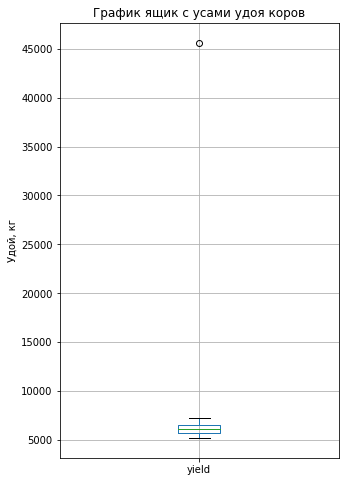

In [23]:
df_main.boxplot('yield',
    grid=True, figsize=(5, 8))
plt.title("График ящик с усами удоя коров")
# Добавление меток осей
plt.ylabel('Удой, кг')

# Отображение графика
plt.show()

На графике удоя коров выявлен 1 статистический выброс. Рассмотрим его и обработаем.

In [24]:
df_main.loc[df_main['yield'] >= 9000]

,id,yield,energy_feed_unit,crude_protein,sugar_protein_ratio,breed,pasture_type,dad_breed,fat_content,protein,taste,age
16,17,45616,11.5,1675,0.93,Вис Бик Айдиал,холмистое,Айдиал,3.22,3.076,вкусно,более_2_лет


Удой в 45 616 кг не выглядит правдоподобным. Можно было бы предположить, что при внесении данных забыли проставить запятую, ооднако тогда удой в 4516,6 кг также будет являться выбросом. Удалим эту строку. На азмерность датасета это повлияет не сильно.

In [25]:
df_main = df_main.loc[df_main['yield'] <= 9000]

Построим график заново.

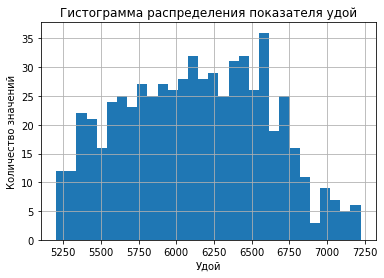

In [26]:
df_main['yield'].hist(bins=30)
plt.title('Гистограмма распределения показателя удой')
plt.xlabel('Удой')
plt.ylabel('Количество значений')
plt.show()

Максимальное значение удоя находится приблизительно на уровне 6600 кг/год. Данные распределены условно нормально. График не симметричный относительно максимума: слева планомерное уменьшение количества наблюдений по мере отдаления от максимального значения, а справа резкое снижение количества наблюдений. Малое количество наблюдений для высокого уровня удоя может повлиять на точность прогнозирования.

### Анализ показателя питательности корма коровы

In [27]:
df_main['energy_feed_unit'].describe()

count    628.000000
mean      14.548726
std        1.301777
min       10.900000
25%       13.500000
50%       14.700000
75%       15.600000
max       16.800000
Name: energy_feed_unit, dtype: float64

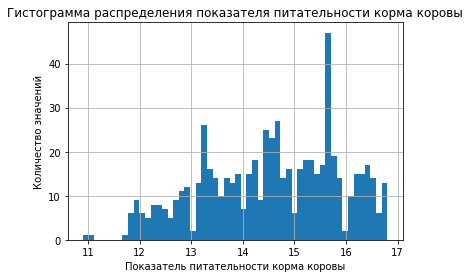

In [28]:
df_main['energy_feed_unit'].hist(bins=54)
plt.title('Гистограмма распределения показателя питательности корма коровы')
plt.xlabel('Показатель питательности корма коровы')
plt.ylabel('Количество значений')
plt.show()

На гистограмме показателя питательности корма коров выделяется значение 14,7 - это самое распространенное значение - более 45 наблюдений. Данные распределены не нормально. Большая часть показателей имеют 10-20 наблюдений, т.е. их количество не уменьшается и не увеличивается относительно максимального. Есть выброс на показателе ЭКЕ в 11, однако удалять его нецелесообразно, т.к. возможно это чем-то обусловлено и общую картину сильно не исказит. 

### Анализ показателя содержания сырого протеина в корме

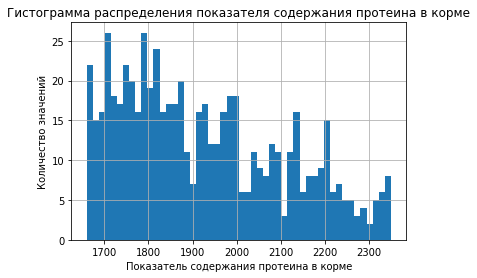

In [29]:
df_main['crude_protein'].hist(bins=50)
plt.title('Гистограмма распределения показателя содержания протеина в корме')
plt.xlabel('Показатель содержания протеина в корме')
plt.ylabel('Количество значений')
plt.show()

Данные распределены не нормально. Показатель содержания протеина в корме находится в диапазоне 1650 - 2350 г. Самый частовстречаемый показатель - 1700 и по мере увеличения этого показателя частота его появления уменьшается. Статистические выбросы отсутствуют. 

### Анализ показателя СПО (Сахаро-протеиновое соотношение)

In [30]:
df_main['sugar_protein_ratio'].describe()

count    628.000000
mean       0.913089
std        0.032221
min        0.840000
25%        0.890000
50%        0.930000
75%        0.940000
max        0.960000
Name: sugar_protein_ratio, dtype: float64

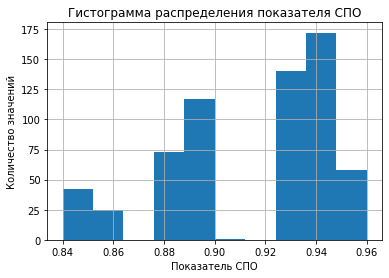

In [31]:
df_main['sugar_protein_ratio'].hist(bins=10)
plt.title('Гистограмма распределения показателя СПО')
plt.xlabel('Показатель СПО')
plt.ylabel('Количество значений')
plt.show()

Данные по СПО также распределены не нормально. Выделяются три группы наблюдений с увеличивающимся количеством наблюдений 0,84-0,86, 0,88-0,9 и 0,93-0,96. Медианное значение СПО (Сахаро-протеиновое соотношение) находится на уровне 0,93. Межквартильный разброс - 0,05 кг. Статистические выбросы отсутствуют.

### Анализ показателя породы коров

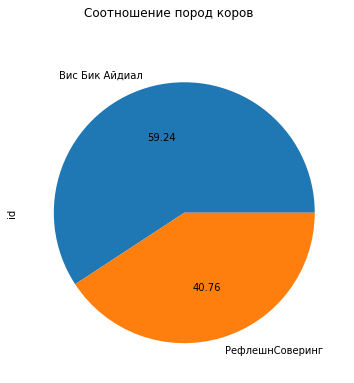

In [32]:
#фильтруем таблицу, группируем и строим график
df_main.pivot_table(index='breed', values='id', aggfunc='count').plot(
    kind='pie',
    autopct='%.2f',
    subplots=True,
    grid=True, 
    figsize=(17, 6),
    legend=False,
    title='Соотношение пород коров'
)
# Отображение графика
plt.show()

В стаде заказчика два вида коров. Преобладают коровы породы Вис Бик Айдиал.

### Анализ показателя тип пастбища

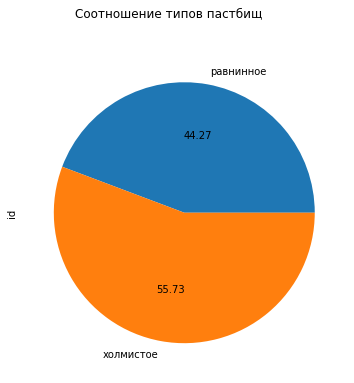

In [33]:
#фильтруем таблицу, группируем и строим график
df_main.pivot_table(index='pasture_type', values='id', aggfunc='count').plot(
    kind='pie',
    autopct='%.2f',
    subplots=True,
    grid=True, 
    figsize=(17, 6),
    legend=False,
    title='Соотношение типов пастбищ'
)
# Отображение графика
plt.show()

В стаде заказчика коровы пасутся в равнинной и холмистой местностях. Преобладают холмистые пастбища.

### Анализ показателя порода папы коровы

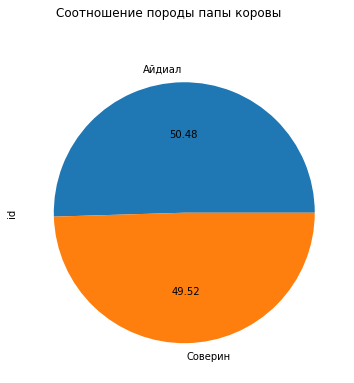

In [34]:
#фильтруем таблицу, группируем и строим график
df_main.pivot_table(index='dad_breed', values='id', aggfunc='count').plot(
    kind='pie',
    autopct='%.2f',
    subplots=True,
    grid=True, 
    figsize=(17, 6),
    legend=False,
    title='Соотношение породы папы коровы'
)
# Отображение графика
plt.show()

В стаде заказчика папы коров представлены двумя породами: Айдиал и Соверин. Соотношение практически одинаковое.

### Анализ показателя  содержание жиров в молоке

In [35]:
df_main['fat_content'].describe()

count    628.000000
mean       3.604268
std        0.168093
min        2.990000
25%        3.590000
50%        3.650000
75%        3.720000
max        3.750000
Name: fat_content, dtype: float64

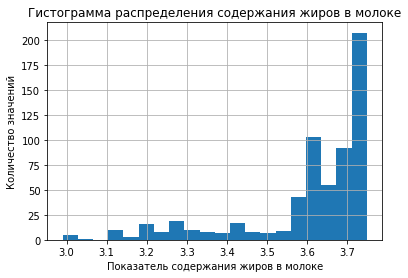

In [36]:
df_main['fat_content'].hist(bins=20)
plt.title('Гистограмма распределения содержания жиров в молоке')
plt.xlabel('Показатель содержания жиров в молоке')
plt.ylabel('Количество значений')
plt.show()

Данные по жирности распределены не нормально: самое частовстреаемое значние в 3,75% является максимальным. Справа нет значений, а слева две ступени: 3,55-3,65% имеют среднее количество наблюдений, вторая ступень (3-3,55%) - имеют практически равное минимальное количество наблюдений.

### Анализ показателя  содержание белков в молоке 

In [37]:
df_main['protein'].describe()

count    628.000000
mean       3.075670
std        0.002551
min        3.069000
25%        3.074000
50%        3.076000
75%        3.077000
max        3.085000
Name: protein, dtype: float64

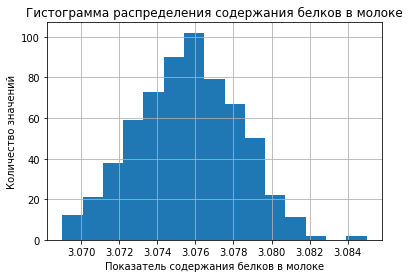

In [38]:
df_main['protein'].hist(bins=15)
plt.title('Гистограмма распределения содержания белков в молоке')
plt.xlabel('Показатель содержания белков в молоке')
plt.ylabel('Количество значений')
plt.show()

Показатель содержания белков в молоке распределен нормально. Симметричный график вокруг значения 3,076г. 

### Анализ показателя  вкус молока

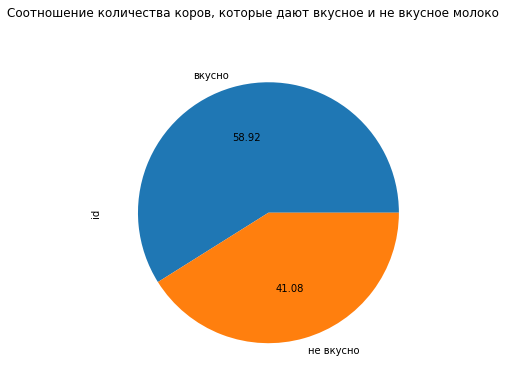

In [39]:
#фильтруем таблицу, группируем и строим график
df_main.pivot_table(index='taste', values='id', aggfunc='count').plot(
    kind='pie',
    autopct='%.2f',
    subplots=True,
    grid=True, 
    figsize=(17, 6),
    legend=False,
    title='Соотношение количества коров, которые дают вкусное и не вкусное молоко'
)
# Отображение графика
plt.show()

Целевой показатель вкуса молока представлен двумя вариантами: вкусное молоко и не вкусное. По мнению заказчика почти 59% коров в стаде дают вкусное молоко.

### Анализ показателя  возраст коров

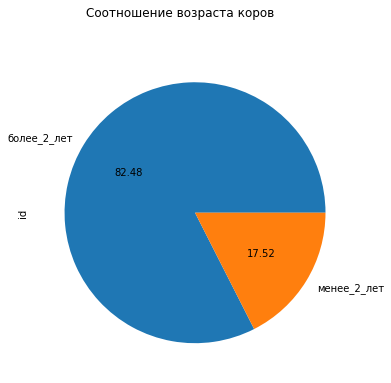

In [40]:
#фильтруем таблицу, группируем и строим график
df_main.pivot_table(index='age', values='id', aggfunc='count').plot(
    kind='pie',
    autopct='%.2f',
    subplots=True,
    figsize=(17, 6),
    legend=False,
    title='Соотношение возраста коров'
)
# Отображение графика
plt.show()

Возраст коров также представлен в бинарном варианте: возрас до 2-х лет и менее 2-х лет. В стаде преобладают взрослые особи.

**Вывод:** 

Данные достаточно репрезентативные, статистические выбросы отсутствуют или устранены. 

Единственный признак, который распределен нормально это показатель содержания белков в молоке.

Данные по удою распределены условно нормально. График не симметричный относительно максимума: слева планомерное уменьшение количества наблюдений по мере отдаления от максимального значения, а справа резкое снижение количества наблюдений. Малое количество наблюдений для высокого уровня удоя может повлиять на точность прогнозирования.

Остальный количественные признаки распределены не нормально: 
1) ЭКЕ: Большая часть показателей имеют 10-20 наблюдений. Их количество не уменьшается и не увеличивается относительно максимального.

2) Содержание протеина в корме: Показатель содержания протеина в корме находится в диапазоне 1650 - 2350 г. Самый частовстречаемый показатель - 1700 и по мере увеличения этого показателя частота его появления уменьшается.

3) СПО: Выделяются три группы наблюдений с увеличивающимся количеством наблюдений 0,84-0,86, 0,88-0,9 и 0,93-0,96.

4) Жирность молока: самое частовстреаемое значние в 3,75% является максимальным. Справа нет значений, а слева две ступени: 3,55-3,65% имеют среднее количество наблюдений, вторая ступень (3-3,55%) - имеют практически равное минимальное количество наблюдений.

## Корреляционный анализ

Построим матрицу корреляции между количественными признаками.

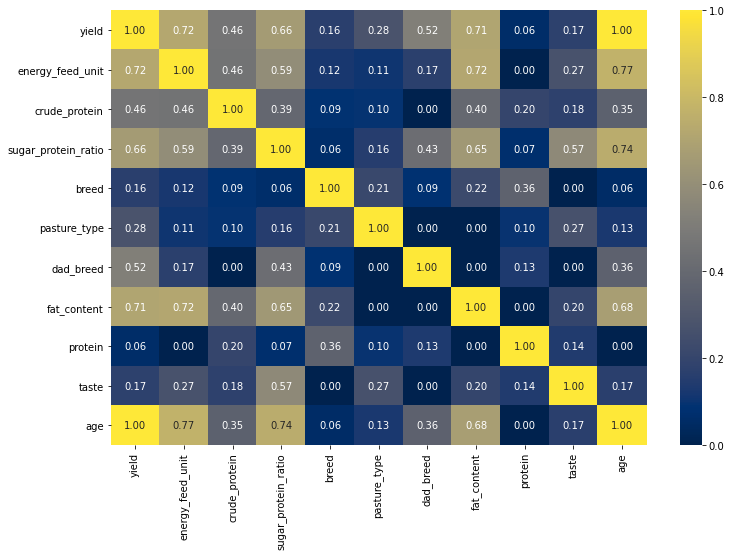

In [41]:
plt.figure(figsize=(12, 8))

sns.heatmap(df_main.drop('id', axis=1).phik_matrix(interval_cols=['yield','energy_feed_unit',
                                                                  'crude_protein',
                                                                  'sugar_protein_ratio',
                                                                  'fat_content',
                                                                  'protein'
                                                                 ]
                                                  ), annot=True, cmap='cividis', fmt='.2f')

plt.show()

Согласно матрице удой достаточно сильно зависит от показетелей корма коров: ЭКЕ (0,72), сырой протеин в корме (0,46) и СПО (0,66). Также есть зависимость удоя и процента жиронсти молока (0,71), что не логично. Возможно это совпадение, а может быть закономерность. Выясним это позже, когда построим модель регрессии. Между остальными признаками также прослеживается достаточно сильная взаимосвязь. Выделяется на общем фоне показатель белка в молоке - этот параметр показывает слабую корреляцию с остальными признаками.  

Рассмотрим на графиках зависимости целевого показателя и остальных численных параметров в разрезе по категориальным признакам.

In [42]:
#определяем переменную для работы фунции
category = ['breed', 'pasture_type', 'dad_breed', 'taste', 'age']
#создаем функцию для вывода нескольких графиков по каждой количественной переменной 
def scatter (nc):
    try:
        for i in category:
            sns.scatterplot(data=df_main, x=nc, y="yield", hue=i)
            grid=True
            plt.xlabel(df.columns[df_main.columns.get_loc(nc)])
            plt.ylabel("Удой, кг")
            plt.legend(title=df.columns[df_main.columns.get_loc(i)], loc='upper left')
            plt.show()
    except:
        for i in category:
            sns.scatterplot(data=df_main, x=nc, y="yield", hue=i)
            grid=True
            plt.ylabel("Удой, кг")
            plt.legend(title=df.columns[df_main.columns.get_loc(i)], loc='upper left')
            plt.show()

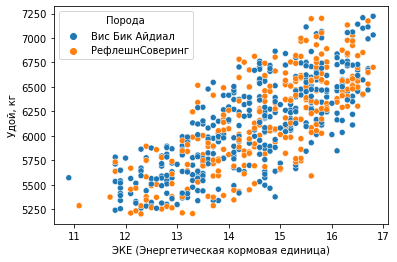

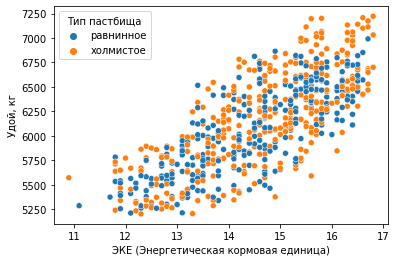

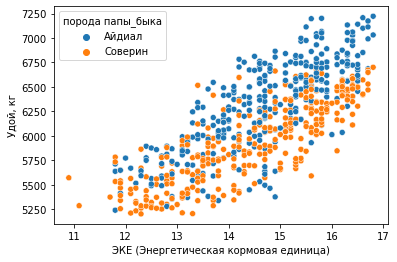

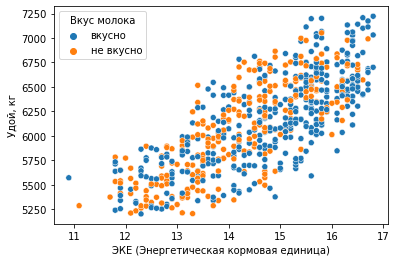

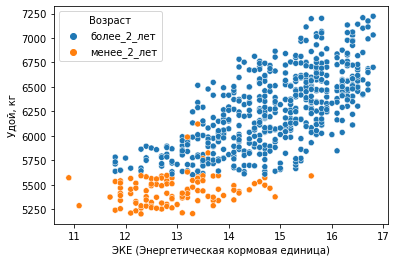

In [43]:
scatter('energy_feed_unit')

Между ЭКЕ и целевым признаком прослеживается четкая прямая нелинейная зависимость. Также из графиков можно сделать следующие выводы: 
  1) рекордные удои принадлежат коровам, которые паслись на холмистых пастбищах и употребляли корма с показателем ЭКЕ выше 15,5, относятся к породе Айдиал и возрастом больше 2-х лет. 
  
  2) по остальным параметрам каких-то закономерностей не выявлено. 

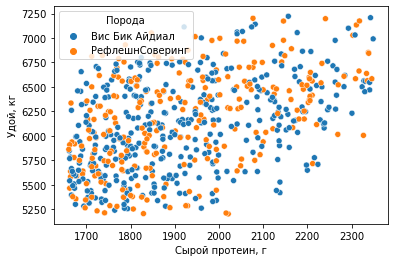

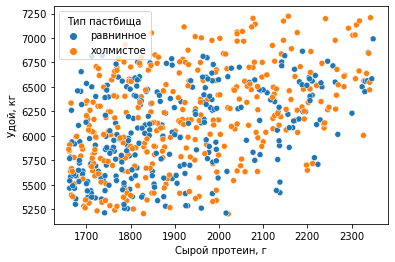

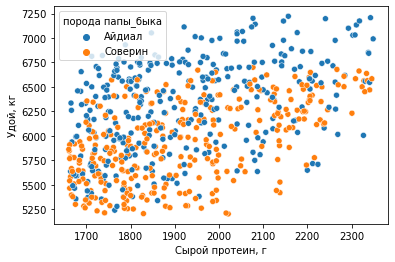

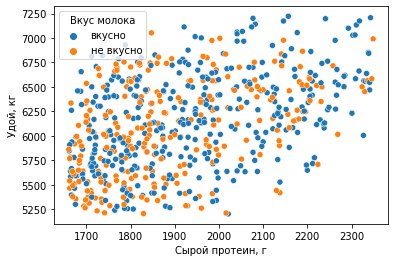

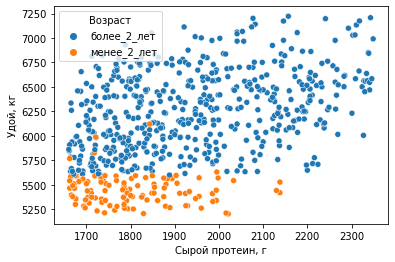

In [44]:
scatter('crude_protein')

Между целевым признаком и содержанием протеина в корме взаимосвязь отсутствует. Закономерности указанные для первой группы графиков подтверждаются.

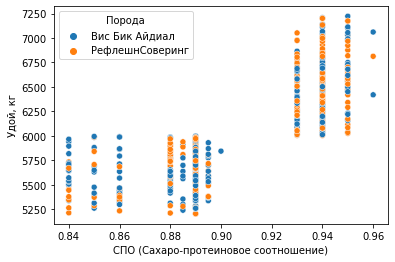

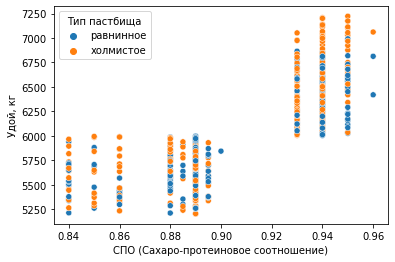

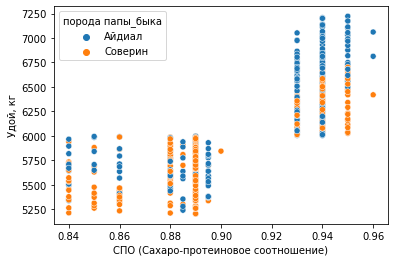

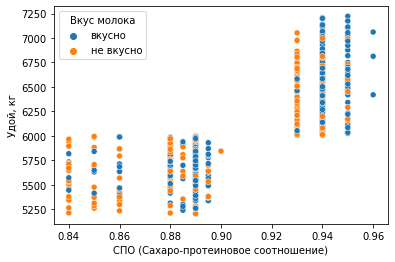

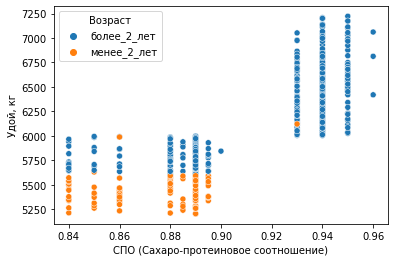

In [45]:
scatter('sugar_protein_ratio')

Между целевым признаком и СПО выявлена нелинейная зависимость. Выражены три группы значений: 0,84-0,86 и 0,88-0,9 характерны для низких значений целевого признака, 0,93-0,95 - для высокого. Закономерности указанные для первой группы графиков также подтверждаются.

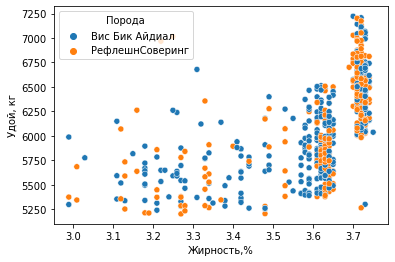

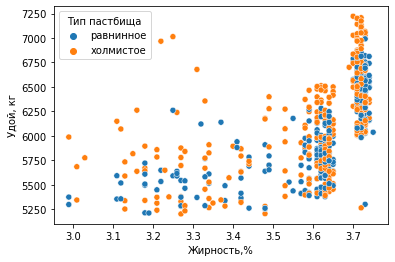

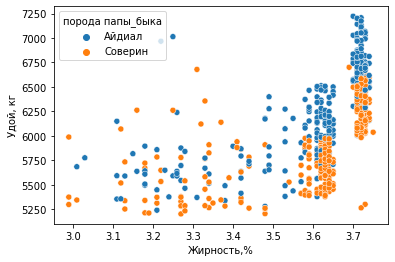

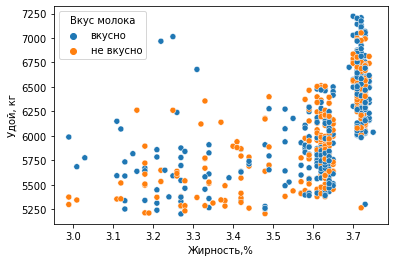

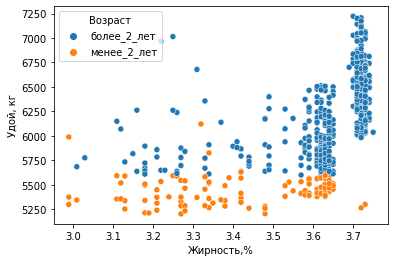

In [46]:
scatter('fat_content')

Между целевым признаком и жирностью молока прослеживается слабая нелинейная зависимость.

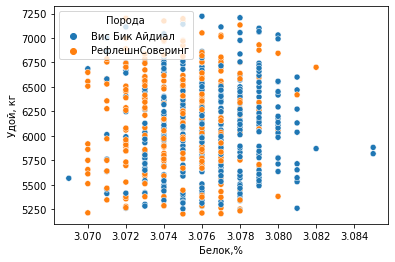

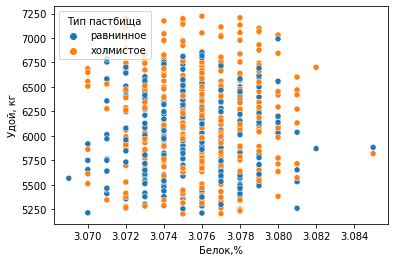

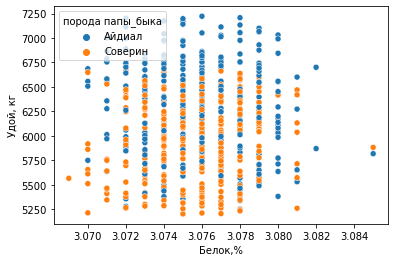

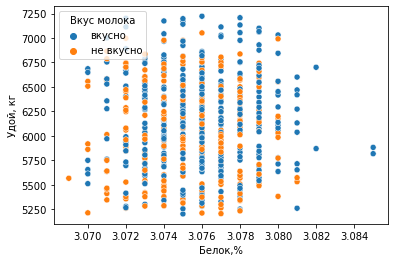

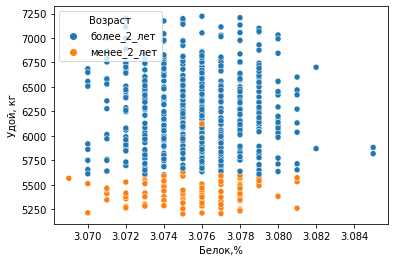

In [47]:
scatter('protein')

Между целевым признаком и содержанием протеина в молоке взаимосвязь отсутствует. Закономерности указанные для первой группы графиков подтверждаются.

**Вывод:**

1) Выявленные нелинейные зависимости со следующими параметрами: ЭКЕ, жирность молока и СПО. Их можно классифицировать или добавить новый искусственный парамерт в виде квадрата от оригинала.

2) Мультиколинеарность параметров не выявлена.

3) Дополнительные выводы относительно категориальных параметров: рекордные удои принадлежат коровам, которые паслись на холмистых пастбищах и употребляли корма с показателем ЭКЕ выше 15,5, относятся к породе Айдиал и возрастом больше 2-х лет.

## Обучение модели линейной регрессии

### Первая модель линейной регрессии

Построим первую модель линейной регрессии. Целевой признак - удой. Возьмем предобработанный датасет, уберем столбцы, которые нерелевантны целевому признаку и обучим модель. Из датасета, котором будет проводиться обучение модели исключены столбцы, которые харатеризуют качественные параметры молока и не влияют на удой не смотря на то, что были выявлены зависимости этих параметров от целевог признака. В модель включены параметры корма коров, что логично. Также по ним выявлены зависимости от целевого признака. Другие категориальные признаки также будут участвовать в обучающей модели, т.к. возможно закономерности есть, но они не очевидны.

In [48]:
#удаляем лишние столбцы
df_main_filter = df_main.drop(['id', 'fat_content', 'protein', 'taste'], axis=1).copy()
df_main_filter.head()

,yield,energy_feed_unit,crude_protein,sugar_protein_ratio,breed,pasture_type,dad_breed,age
0,5863,14.2,1743,0.890,Вис Бик Айдиал,равнинное,Айдиал,более_2_лет
1,5529,12.8,2138,0.890,Вис Бик Айдиал,равнинное,Соверин,менее_2_лет
2,5810,14.0,1854,0.885,РефлешнСоверинг,холмистое,Соверин,более_2_лет
3,5895,12.4,2012,0.885,РефлешнСоверинг,холмистое,Айдиал,более_2_лет
4,5302,12.8,1675,0.885,Вис Бик Айдиал,равнинное,Соверин,менее_2_лет


In [49]:
RANDOM_STATE = 42

X = df_main_filter.drop('yield', axis=1)
y = df_main_filter['yield']

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    random_state=RANDOM_STATE)

cat_col_names = ['breed', 'pasture_type', 'dad_breed', 'age']
num_col_names = ['energy_feed_unit', 'crude_protein', 'sugar_protein_ratio']

# подготовка признаков (масштабирование и кодирование)

encoder = OneHotEncoder(drop='first', sparse=False)
X_train_ohe = encoder.fit_transform(X_train[cat_col_names])
X_test_ohe = encoder.transform(X_test[cat_col_names])

encoder_col_names = encoder.get_feature_names()

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[num_col_names])
X_test_scaled = scaler.transform(X_test[num_col_names])

X_train_ohe = pd.DataFrame(X_train_ohe, columns=encoder_col_names)
X_test_ohe = pd.DataFrame(X_test_ohe, columns=encoder_col_names)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=num_col_names)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=num_col_names)

X_train = pd.concat([X_train_ohe, X_train_scaled], axis=1)
X_test = pd.concat([X_test_ohe, X_test_scaled], axis=1)

# обучение модели и получение предсказаний на тестовых данных
model_lr  = LinearRegression()
model_lr.fit(X_train, y_train)
predictions = model_lr.predict(X_test)

In [50]:
#рассчитываем среднеквадратическое отклонение
mod1_r2 = r2_score(y_test, predictions) 
mod1_r2

0.7844078173416967

Модель объясняет 78,4% дисперсии с данным набором параметров, что достаточно мало. Рассмотрим остатки.

In [51]:
    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = mean_squared_error(y_test, predictions, squared=False)
    r_2 = r2_score(y_test, predictions) 
    print(f'Значение средней абсолютной ошибки {mae.round(2)}')
    print(f'Значение среднеквадратичной ошибки {mse.round(2)}')
    print(f'Значение корня среднеквадратичной ошибки {rmse.round(2)}')

Значение средней абсолютной ошибки 164.24
Значение среднеквадратичной ошибки 43887.02
Значение корня среднеквадратичной ошибки 209.49


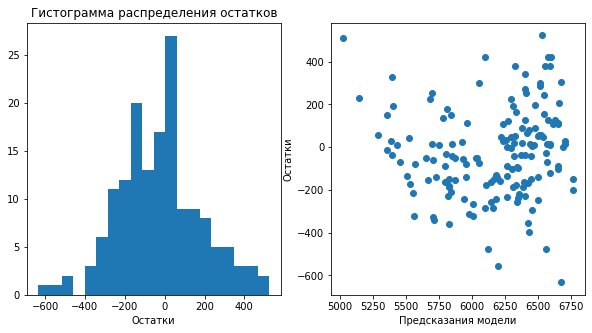

In [52]:
residuals = y_test - predictions
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,5))

axes[0].hist(residuals, bins=20)
axes[0].set_title('Гистограмма распределения остатков')
axes[0].set_xlabel('Остатки')

axes[1].scatter(predictions, residuals)
axes[1].set_xlabel('Предсказания модели')
axes[1].set_ylabel('Остатки')
plt.show()

Остатки распределены нормально с небольшим смещением влево относительно 0. Это говорит о том, что модель чаще завышает предсказания удоя по сравенению с реальными. Дисперсия растет по мере увеличения показателя удоя. Это связано с недостаточным количеством данных по рекордным удоям.


In [53]:
model_lr.coef_

array([  -1.00690622,   50.99203909, -240.31696942, -237.10122082,
        156.86349261,   50.60134732,  162.47801769])

Коэффициенты параметров нормальные.

**Вывод:**
 Из совокупности факторов делаем вывод, что модель работает, но не идельно. Ее можно улучшить.

### Вторая модель линейной регрессии

Проведем обучение второй модели. Оставим состав параметров тот же, но преобразуем уже имеющиеся. В разделе исследовательского анализа было выявлено нелинейный характер зависимости ЭКЕ и СПО от целевого признака. Избавимся от нелинейности переведя СПО в бинарный категориальный признак, а ЭКЕ возведением в квадрат. 

In [54]:
def spr(row): #добавляем функцию, которая опреледяет категорию СПО, порог 0,92 определен ранее
    if row['sugar_protein_ratio'] <= 0.92:
        return 'низкий СПО'
    else:
        return 'высокий СПО'
df_main['cat_sugar_protein_ratio'] = df_main.apply(spr, axis=1)#создаем новый столбец

In [55]:
#создаем столбец с показателем ЭКЕ в квадрате
df_main['sq_energy_feed_unit'] = df_main['energy_feed_unit'] ** 2

In [56]:
#убираем лишние столбцы из датафрейма и проверяем результат
df_main_filter_v2 = df_main.drop(['energy_feed_unit',
                           'sugar_protein_ratio',
                           'id',
                           'fat_content',
                           'protein',
                           'taste'] , axis=1).copy()
df_main_filter_v2.head()

,yield,crude_protein,breed,pasture_type,dad_breed,age,cat_sugar_protein_ratio,sq_energy_feed_unit
0,5863,1743,Вис Бик Айдиал,равнинное,Айдиал,более_2_лет,низкий СПО,201.64
1,5529,2138,Вис Бик Айдиал,равнинное,Соверин,менее_2_лет,низкий СПО,163.84
2,5810,1854,РефлешнСоверинг,холмистое,Соверин,более_2_лет,низкий СПО,196.00
3,5895,2012,РефлешнСоверинг,холмистое,Айдиал,более_2_лет,низкий СПО,153.76
4,5302,1675,Вис Бик Айдиал,равнинное,Соверин,менее_2_лет,низкий СПО,163.84


In [57]:
RANDOM_STATE = 42

X = df_main_filter_v2.drop('yield', axis=1)
y = df_main_filter_v2['yield']

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    random_state=RANDOM_STATE)

cat_col_names = ['breed', 'pasture_type', 'dad_breed', 'age', 'cat_sugar_protein_ratio']
num_col_names = ['sq_energy_feed_unit', 'crude_protein']

## подготовка признаков (масштабирование и кодирование)

encoder = OneHotEncoder(drop='first', sparse=False)
X_train_ohe = encoder.fit_transform(X_train[cat_col_names])
X_test_ohe = encoder.transform(X_test[cat_col_names])

encoder_col_names = encoder.get_feature_names()

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[num_col_names])
X_test_scaled = scaler.transform(X_test[num_col_names])

X_train_ohe = pd.DataFrame(X_train_ohe, columns=encoder_col_names)
X_test_ohe = pd.DataFrame(X_test_ohe, columns=encoder_col_names)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=num_col_names)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=num_col_names)

X_train = pd.concat([X_train_ohe, X_train_scaled], axis=1)
X_test = pd.concat([X_test_ohe, X_test_scaled], axis=1)

# обучение модели и получение предсказаний на тестовых данных
model_lr_2  = LinearRegression()
model_lr_2.fit(X_train, y_train)
predictions_2 = model_lr_2.predict(X_test)

In [58]:
mod2_r2 = r2_score(y_test, predictions_2) 
mod2_r2

0.8180879926867501

Модель объясняет 81,8% дисперсии с данным набором параметров, что достаточно мало. Этот показатель лучше предыдущего на 3,4 процентных пункта, но все еще мало. Рассмотрим остатки.

In [59]:
    mae = mean_absolute_error(y_test, predictions_2)
    mse = mean_squared_error(y_test, predictions_2)
    rmse = mean_squared_error(y_test, predictions_2, squared=False)
    r_2 = r2_score(y_test, predictions_2) 
    print(f'Значение средней абсолютной ошибки {mae.round(2)}')
    print(f'Значение среднеквадратичной ошибки {mse.round(2)}')
    print(f'Значение корня среднеквадратичной ошибки {rmse.round(2)}')

Значение средней абсолютной ошибки 149.04
Значение среднеквадратичной ошибки 37030.91
Значение корня среднеквадратичной ошибки 192.43


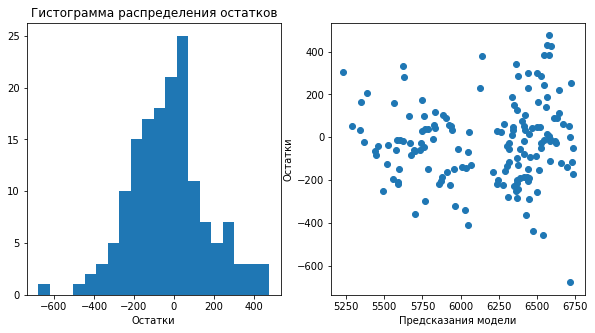

In [60]:
residuals_2 = y_test - predictions_2
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,5))

axes[0].hist(residuals_2, bins=20)
axes[0].set_title('Гистограмма распределения остатков')
axes[0].set_xlabel('Остатки')

axes[1].scatter(predictions_2, residuals_2)
axes[1].set_xlabel('Предсказания модели')
axes[1].set_ylabel('Остатки')
plt.show()

Остатки как и в первой модели распределены нормально со смещением влево относительно 0. Дисперсия стала визуально более равномерной на всей оси X, однако также наблюдаются выбросы на больших значениях удоя.

In [61]:
model_lr_2.coef_

array([   4.39943158,   32.63784878, -211.46306698, -224.70941045,
       -377.12043646,  154.17990643,   49.13121937])

Коэффициенты параметров также нормальные.

**Вывод:**
 Вторая модель стала лучше: без объяснений осталось 18,2% от дисперсии, остатки распеределены более равномено, с меньшим смещением, однако есть возможность ее еще улучшить.

### Третья модель линейной регрессии

Возьмем датасет второй модели, добавим новый параметр - имя папы коровы и построим новую модель.

In [62]:
#Добавляем новый столбец
df_main_dad = df_main.merge(df_dad, on='id').copy()
df_main_dad.head()

,id,yield,energy_feed_unit,crude_protein,sugar_protein_ratio,breed,pasture_type,dad_breed,fat_content,protein,taste,age,cat_sugar_protein_ratio,sq_energy_feed_unit,dad_name
0,1,5863,14.2,1743,0.890,Вис Бик Айдиал,равнинное,Айдиал,3.58,3.076,вкусно,более_2_лет,низкий СПО,201.64,Буйный
1,2,5529,12.8,2138,0.890,Вис Бик Айдиал,равнинное,Соверин,3.54,3.079,вкусно,менее_2_лет,низкий СПО,163.84,Соловчик
2,3,5810,14.0,1854,0.885,РефлешнСоверинг,холмистое,Соверин,3.59,3.074,не вкусно,более_2_лет,низкий СПО,196.00,Барин
3,4,5895,12.4,2012,0.885,РефлешнСоверинг,холмистое,Айдиал,3.40,3.075,не вкусно,более_2_лет,низкий СПО,153.76,Буйный
4,5,5302,12.8,1675,0.885,Вис Бик Айдиал,равнинное,Соверин,3.73,3.073,вкусно,менее_2_лет,низкий СПО,163.84,Барин


In [63]:
#преобразуем СПО в категориальный признак
df_main_dad['cat_sugar_protein_ratio'] = df_main_dad.apply(spr, axis=1)

In [64]:
#создаем столбец с показателем ЭКЕ в квадрате
df_main_dad['sq_energy_feed_unit'] = df_main_dad['energy_feed_unit'] ** 2

In [65]:
#Удаляем лишний столбцы и проверяем
df_main_dad_filter = df_main_dad.drop(['energy_feed_unit',
                           'sugar_protein_ratio',
                           'id',
                           'fat_content',
                           'protein',
                           'taste',
                           'dad_breed'] , axis=1).copy()
df_main_dad_filter.head()

,yield,crude_protein,breed,pasture_type,age,cat_sugar_protein_ratio,sq_energy_feed_unit,dad_name
0,5863,1743,Вис Бик Айдиал,равнинное,более_2_лет,низкий СПО,201.64,Буйный
1,5529,2138,Вис Бик Айдиал,равнинное,менее_2_лет,низкий СПО,163.84,Соловчик
2,5810,1854,РефлешнСоверинг,холмистое,более_2_лет,низкий СПО,196.00,Барин
3,5895,2012,РефлешнСоверинг,холмистое,более_2_лет,низкий СПО,153.76,Буйный
4,5302,1675,Вис Бик Айдиал,равнинное,менее_2_лет,низкий СПО,163.84,Барин


In [66]:
RANDOM_STATE = 42

X = df_main_dad_filter.drop('yield', axis=1)
y = df_main_dad_filter['yield']

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    random_state=RANDOM_STATE)

cat_col_names = ['breed', 'pasture_type', 'age', 'cat_sugar_protein_ratio', 'dad_name']
num_col_names = ['sq_energy_feed_unit', 'crude_protein']

## подготовка признаков (масштабирование и кодирование)

encoder = OneHotEncoder(drop='first', sparse=False)
X_train_ohe = encoder.fit_transform(X_train[cat_col_names])
X_test_ohe = encoder.transform(X_test[cat_col_names])

encoder_col_names = encoder.get_feature_names()

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[num_col_names])
X_test_scaled = scaler.transform(X_test[num_col_names])

X_train_ohe = pd.DataFrame(X_train_ohe, columns=encoder_col_names)
X_test_ohe = pd.DataFrame(X_test_ohe, columns=encoder_col_names)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=num_col_names)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=num_col_names)

X_train = pd.concat([X_train_ohe, X_train_scaled], axis=1)
X_test = pd.concat([X_test_ohe, X_test_scaled], axis=1)

# обучение модели и получение предсказаний на тестовых данных
model_lr_3  = LinearRegression()
model_lr_3.fit(X_train, y_train)
predictions_3 = model_lr_3.predict(X_test)

In [67]:
mod3_r2 = r2_score(y_test, predictions_3) 
mod3_r2

0.8265123645098966

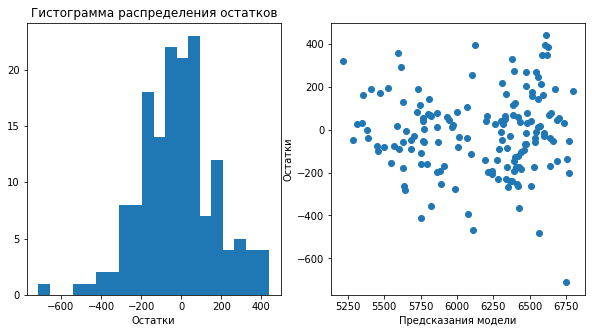

In [68]:
residuals_3 = y_test - predictions_3
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,5))

axes[0].hist(residuals_3, bins=20)
axes[0].set_title('Гистограмма распределения остатков')
axes[0].set_xlabel('Остатки')

axes[1].scatter(predictions_3, residuals_3)
axes[1].set_xlabel('Предсказания модели')
axes[1].set_ylabel('Остатки')
plt.show()

Остатки распределены нормально. Смещение остатков относительно 0 практически отсутствует. Есть выбросы завышающие прогнозные значения в диапазоне 400-600, но их достаточно мало. Распереление дисперсии по оси Х стало еще более равномерным. "Рупор" на графике отсутствует.

In [69]:
model_lr_3.coef_

array([  14.73828234,   48.99909885, -194.01542867, -352.57554051,
        261.88858083,  293.04260391,   23.44314022,  162.34732059,
         52.14491834])

Коэффициенты параметров также нормальные.

**Вывод:**
 Третья модель стала лучше относительно второй: без объяснений осталось 17,3% от дисперсии, остатки распеределены более равномено, без сммещения. Распереление дисперсии по оси Х стало еще более равномерным. "Рупор" на графике отсутствует. Коэффициенты параметров стали нормальными.

### Оценка качества трех моделей

Проведем сравнительный анализ трех моделей.

In [70]:
#создаем функцию, которая выводит основные метрики
def quality(i):
    mae = mean_absolute_error(y_test, i)
    mse = mean_squared_error(y_test, i)
    rmse = mean_squared_error(y_test, i, squared=False)
    r_2 = r2_score(y_test, i) 
    print(f'Значение средней абсолютной ошибки {mae.round(2)}')
    print(f'Значение среднеквадратичной ошибки {mse.round(2)}')
    print(f'Значение корня среднеквадратичной ошибки {rmse.round(2)}')
    print(f'Значение коэффициента детерминации  {r_2.round(2)}')

In [71]:
#выводим метрики первой модели
quality(predictions)

Значение средней абсолютной ошибки 164.24
Значение среднеквадратичной ошибки 43887.02
Значение корня среднеквадратичной ошибки 209.49
Значение коэффициента детерминации  0.78


In [72]:
#выводим метрики второй модели
quality(predictions_2)

Значение средней абсолютной ошибки 149.04
Значение среднеквадратичной ошибки 37030.91
Значение корня среднеквадратичной ошибки 192.43
Значение коэффициента детерминации  0.82


In [73]:
#выводим метрики третьей модели
quality(predictions_3)

Значение средней абсолютной ошибки 144.64
Значение среднеквадратичной ошибки 35316.0
Значение корня среднеквадратичной ошибки 187.93
Значение коэффициента детерминации  0.83


По всем трем метрикам лучшие показатели у третьей модели. Рассчитаем доверительный интервал прогноза третьей модели.

In [74]:
errors = y_test - predictions_3
quantiles=(0.025, 0.975)

lower_quantile = np.quantile(errors, quantiles[0])
upper_quantile = np.quantile(errors, quantiles[1])

print(f"Доверительный интервал прогноза: [{lower_quantile}, {upper_quantile}]")

Доверительный интервал прогноза: [-393.15448638853786, 357.6000355512234]


**Вывод:**
 Третья модель по всем метрикам лучше остальных моделей. Принято решение использовать ее для прогнозирования удоя коров рассматриваемых к приобретению.


### Расчер прогнозного значения удоя коров к приобретению

Сделаем прогноз удойности коров Экофермы на основе третьей модели. Данные по корму коров(ЭКЕ, протеин, СПО) в модели используются, но в датасете не представлены. Заказчик сообщил, что планирует изменить подход к характеристикам корма и всех новых коров будут кормить как среднее значнение от текущеих показателей +5%. Рассчитаем эти показатели, сделаем подготовку датасета и сделаем прогноз удойности.

In [75]:
df_buy['energy_feed_unit'] = df_main['energy_feed_unit'].mean()*1.05
df_buy['crude_protein'] = df_main['crude_protein'].mean()*1.05
df_buy['sugar_protein_ratio'] = df_main['sugar_protein_ratio'].mean()*1.05

In [76]:
#меняем столбцы таблицы
df_buy['cat_sugar_protein_ratio'] = df_buy.apply(spr, axis=1)
df_buy['sq_energy_feed_unit'] = df_buy['energy_feed_unit'] ** 2
df_buy

,breed,pasture_type,dad_breed,dad_name,fat_content_current,protein_current,age,energy_feed_unit,crude_protein,sugar_protein_ratio,cat_sugar_protein_ratio,sq_energy_feed_unit
0,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,3.58,3.076,более_2_лет,15.276162,2019.947532,0.958744,высокий СПО,233.361138
1,Вис Бик Айдиал,равнинное,Соверин,Буйный,3.54,3.081,менее_2_лет,15.276162,2019.947532,0.958744,высокий СПО,233.361138
2,РефлешнСоверинг,равнинное,Соверин,Барин,3.59,3.074,более_2_лет,15.276162,2019.947532,0.958744,высокий СПО,233.361138
3,РефлешнСоверинг,холмистое,Айдиал,Буйный,3.40,3.061,более_2_лет,15.276162,2019.947532,0.958744,высокий СПО,233.361138
4,РефлешнСоверинг,равнинное,Айдиал,Буйный,3.64,3.074,более_2_лет,15.276162,2019.947532,0.958744,высокий СПО,233.361138
5,РефлешнСоверинг,равнинное,Соверин,Геркулес,3.63,3.053,менее_2_лет,15.276162,2019.947532,0.958744,высокий СПО,233.361138
6,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,3.58,3.076,более_2_лет,15.276162,2019.947532,0.958744,высокий СПО,233.361138
7,Вис Бик Айдиал,равнинное,Соверин,Буйный,3.57,3.079,более_2_лет,15.276162,2019.947532,0.958744,высокий СПО,233.361138
8,РефлешнСоверинг,равнинное,Соверин,Барин,3.59,3.074,более_2_лет,15.276162,2019.947532,0.958744,высокий СПО,233.361138
9,РефлешнСоверинг,холмистое,Айдиал,Буйный,3.40,3.079,менее_2_лет,15.276162,2019.947532,0.958744,высокий СПО,233.361138


In [77]:
#удаляем лишние столбцы
df_buy_filter = df_buy.drop(['fat_content_current',
                             'protein_current',
                             'sugar_protein_ratio',
                             'energy_feed_unit',
                             'dad_breed'], axis=1).copy()
df_buy_filter.head()

,breed,pasture_type,dad_name,age,crude_protein,cat_sugar_protein_ratio,sq_energy_feed_unit
0,Вис Бик Айдиал,холмистое,Геркулес,более_2_лет,2019.947532,высокий СПО,233.361138
1,Вис Бик Айдиал,равнинное,Буйный,менее_2_лет,2019.947532,высокий СПО,233.361138
2,РефлешнСоверинг,равнинное,Барин,более_2_лет,2019.947532,высокий СПО,233.361138
3,РефлешнСоверинг,холмистое,Буйный,более_2_лет,2019.947532,высокий СПО,233.361138
4,РефлешнСоверинг,равнинное,Буйный,более_2_лет,2019.947532,высокий СПО,233.361138


In [78]:
#проверяем результат
df_main_dad_filter.head()

,yield,crude_protein,breed,pasture_type,age,cat_sugar_protein_ratio,sq_energy_feed_unit,dad_name
0,5863,1743,Вис Бик Айдиал,равнинное,более_2_лет,низкий СПО,201.64,Буйный
1,5529,2138,Вис Бик Айдиал,равнинное,менее_2_лет,низкий СПО,163.84,Соловчик
2,5810,1854,РефлешнСоверинг,холмистое,более_2_лет,низкий СПО,196.00,Барин
3,5895,2012,РефлешнСоверинг,холмистое,более_2_лет,низкий СПО,153.76,Буйный
4,5302,1675,Вис Бик Айдиал,равнинное,менее_2_лет,низкий СПО,163.84,Барин


In [79]:
X_buy_ohe = encoder.transform(df_buy_filter[cat_col_names])
X_buy_scaled = scaler.transform(df_buy_filter[num_col_names])
X_buy_ohe = pd.DataFrame(X_buy_ohe, columns=encoder_col_names)
X_buy_scaled = pd.DataFrame(X_buy_scaled, columns=num_col_names)
X_buy = pd.concat([X_buy_ohe, X_buy_scaled], axis=1)
predictions_yield_buy = model_lr_3.predict(X_buy)

In [80]:
predictions_yield_buy = predictions_yield_buy.round(0)
predictions_yield_buy

array([6608., 6334., 6281., 6592., 6543., 6380., 6608., 6528., 6281.,
       6398., 6339., 6574., 6608., 6121., 6281., 6592., 6339., 6380.,
       6528., 6543.])

**Вывод:**
Полученные результаты предсказаний по всем 20 коровам больше порогового значения в 6000 кг/год.

## Обучение модели логистической регрессии

### Подготовка данных и обучение модели

Построим модель логистической регрессии, чтобы предсказать классы вкуса молока коров, предлагаемых к приобретению. В модели буду участвовать параметры характеризующие молоко (жирность, белок), параметры коровы и параметры корма коров.

In [81]:
#добавляем столбец с именем папы коров
df_main_filter_log = df_main.merge(df_dad, on='id').copy()

In [82]:
#удаляем лишние столбцы
df_main_filter_log = df_main_filter_log.drop(['yield',
                                              'id',
                                              'energy_feed_unit',
                                              'cat_sugar_protein_ratio',
                                              'dad_breed'], axis=1).copy()

In [83]:
#кодируем целевой признак и проверяем результат изменений
df_main_filter_log.replace('не вкусно', 0, regex=True, inplace=True)
df_main_filter_log.replace('вкусно', 1, regex=True, inplace=True)
df_main_filter_log

,crude_protein,sugar_protein_ratio,breed,pasture_type,fat_content,protein,taste,age,sq_energy_feed_unit,dad_name
0,1743,0.890,Вис Бик Айдиал,равнинное,3.58,3.076,1,более_2_лет,201.64,Буйный
1,2138,0.890,Вис Бик Айдиал,равнинное,3.54,3.079,1,менее_2_лет,163.84,Соловчик
2,1854,0.885,РефлешнСоверинг,холмистое,3.59,3.074,0,более_2_лет,196.00,Барин
3,2012,0.885,РефлешнСоверинг,холмистое,3.40,3.075,0,более_2_лет,153.76,Буйный
4,1675,0.885,Вис Бик Айдиал,равнинное,3.73,3.073,1,менее_2_лет,163.84,Барин
...,...,...,...,...,...,...,...,...,...,...
623,1964,0.940,РефлешнСоверинг,равнинное,3.74,3.075,0,более_2_лет,237.16,Буйный
624,1700,0.880,РефлешнСоверинг,равнинное,3.64,3.073,1,менее_2_лет,166.41,Барин
625,1837,0.880,РефлешнСоверинг,холмистое,3.64,3.075,0,более_2_лет,207.36,Барин
626,1994,0.890,РефлешнСоверинг,равнинное,3.64,3.077,1,более_2_лет,190.44,Барин


In [84]:
X = df_main_filter_log.drop('taste', axis=1)
y = df_main_filter_log['taste']

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    random_state=RANDOM_STATE)

cat_col_names = ['breed', 'pasture_type', 'age', 'dad_name']
num_col_names = ['fat_content', 'protein', 'sq_energy_feed_unit', 'crude_protein', 'sugar_protein_ratio']

## подготовка признаков (масштабирование и кодирование)

encoder = OneHotEncoder(drop='first', sparse=False)
X_train_ohe = encoder.fit_transform(X_train[cat_col_names])
X_test_ohe = encoder.transform(X_test[cat_col_names])

encoder_col_names = encoder.get_feature_names()

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[num_col_names])
X_test_scaled = scaler.transform(X_test[num_col_names])

X_train_ohe = pd.DataFrame(X_train_ohe, columns=encoder_col_names)
X_test_ohe = pd.DataFrame(X_test_ohe, columns=encoder_col_names)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=num_col_names)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=num_col_names)

X_train = pd.concat([X_train_ohe, X_train_scaled], axis=1)
X_test = pd.concat([X_test_ohe, X_test_scaled], axis=1)

clf = LogisticRegression(random_state=RANDOM_STATE)

clf = clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

In [85]:
#рассчитаем основые метрики полученной модели
acc = accuracy_score(y_test, y_pred) 
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
print(f'Значение accuracy {acc.round(2)}')
print(f'Значение recall {recall.round(2)}')
print(f'Значение precision {precision.round(2)}')

Значение accuracy 0.61
Значение recall 0.85
Значение precision 0.61


Точность модели достаточно низкая - 61%. Модель чаще совершает ошибки второго рода, чем первого. Рассмотрим коэффициенты параметров модели. 

In [86]:
for feature_number, feature_name in enumerate(X_train.columns):
    weight = clf.coef_[0, feature_number]
    print(f"{feature_name:<20}: {weight:+.6f}") 

x0_РефлешнСоверинг  : +0.035228
x1_холмистое        : +0.487228
x2_менее_2_лет      : -0.111454
x3_Буйный           : -0.299721
x3_Геркулес         : -0.252891
x3_Соловчик         : -0.428762
fat_content         : -0.137688
protein             : +0.244739
sq_energy_feed_unit : +0.351908
crude_protein       : +0.085357
sugar_protein_ratio : +0.195466


Все коэффициенты в абсолютном выражении находятся в диапазоне 0,03-0,49. Это говорит о том, что незначительных параметров, которые не имеют веса в модели нет. Построим матрицу ошибок и рассмотрим где чаще ошибается модель.

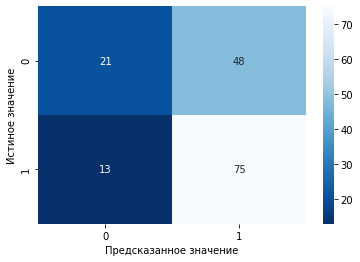

In [87]:
#построение матрицы ошибок
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues_r')
plt.ylabel('Истиное значение')
plt.xlabel('Предсказанное значение');

### Анализ полученной модели

Согласно матрицы ошибок модель чаще совершает ошибки 1-го рода (48 шт) по сравнению с ошибками 2-го рода (13 шт). Для заказчика принципиально важно, чтобы молоко приобретаемых коров было вкусным, т.е. надо увеличить порог вероятности отнесения коров к классу 1 (вкусное молоко) со стандартных 0,5 до такого уровня, чтобы ошибок 1-го рода не осталось совсем. Для этого надо найти такой минимальный порог вероятности, при котором значение метрики precision будет равна 1. При определении классов на основании полученной модели необходимо будет учитывать новый порог, а не стандартный. Выведем таблицу истинных значений тестовой выборки целевого признака, предсказания модели для тестовой выборки и вероятности.

In [88]:
y_proba = clf.predict_proba(X_test)[:,1]

data_2 = pd.DataFrame(zip(y_test, y_proba, y_pred),
             columns = ['y_valid', 'y_proba', 'y_pred']).sort_values(by='y_proba',ascending=False)

print(data_2.head(35)) 

     y_valid   y_proba  y_pred
85         1  0.846346       1
110        1  0.831055       1
17         1  0.819150       1
66         1  0.812558       1
116        0  0.810870       1
114        1  0.806764       1
18         1  0.802479       1
33         0  0.799041       1
136        1  0.797261       1
14         1  0.793633       1
64         1  0.792179       1
35         1  0.785611       1
103        1  0.784095       1
39         1  0.781594       1
11         1  0.775090       1
153        1  0.771227       1
72         1  0.771219       1
8          1  0.768551       1
80         0  0.762825       1
111        0  0.762372       1
7          1  0.760452       1
108        0  0.759905       1
56         1  0.759126       1
146        1  0.756816       1
6          1  0.756524       1
10         1  0.755535       1
106        1  0.754811       1
54         0  0.751294       1
25         1  0.748870       1
151        0  0.748240       1
95         1  0.743851       1
150     

Первая ошибка разряда False Positive встречается на пороге в 0,81. Проверим эту информацию с помощью расчета recall и precision в диапазоне вероятности от 0 до 0,85 с шагом 0.01. 

In [89]:
thresholds = [round(i,2) for i in np.linspace(0.1,0.85,num = 85,endpoint=False)]
precision = []
recall = []
columns = []
for i in thresholds:
    columns.append('y_pred'+str(i))
    data_2['y_pred'] = data_2['y_proba'].apply(lambda x: 1 if x>= i else 0)
    y_pred_threshold = (y_proba >= i).astype(int)
    precision.append(precision_score(y_test, y_pred_threshold))
    recall.append(recall_score(y_test, y_pred_threshold))

data_tresh_pres = pd.DataFrame(zip(columns, precision, recall),columns = ['Порог', 'Значение precision', 'Значение recall']) 
data_tresh_pres.tail(25)

,Порог,Значение precision,Значение recall
60,y_pred0.63,0.692308,0.613636
61,y_pred0.64,0.680000,0.579545
62,y_pred0.65,0.720588,0.556818
63,y_pred0.66,0.723077,0.534091
64,y_pred0.66,0.723077,0.534091
65,y_pred0.67,0.725806,0.511364
66,y_pred0.68,0.745455,0.465909
67,y_pred0.69,0.750000,0.443182
68,y_pred0.7,0.755556,0.386364
69,y_pred0.71,0.767442,0.375000


Precision принимает значение 1 на пороге вероятности в 0,81. При этом значение recall падает до 0,045. Теперь мы знаем порог вероятности отнесения к классу при котором вероятность ошибки получить целевой признак "не вкусное" молоко крайне мал. Построим заново матрицу ошибок.

In [90]:
#выводим предсказания на основании нового порога в 0,813 
y_pred_2 = []
for i in y_proba:
    if i > 0.813:
        y_pred_2.append(1)
    else:
        y_pred_2.append(0)

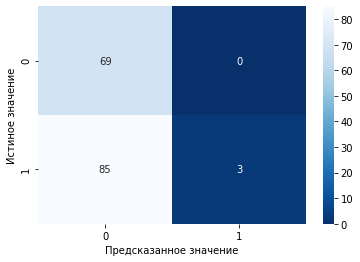

In [91]:
#построение матрицы ошибок
cm = confusion_matrix(y_test, y_pred_2)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues_r')
plt.ylabel('Истиное значение')
plt.xlabel('Предсказанное значение');

При пороге отнесения наблюдений к 1 в 0,81 ложноположительные ошибки отсутствуют. Только трем из 157 присвоено значение "вкусное молоко". Остальным присвоена категория "не вкусное". Соответственно и ошибок второго рода кратно увеличилось с 13 до 85. 

Если обратить внимание на таблицу истинных значений тестовой выборки целевого признака, предсказания модели для тестовой выборки и вероятности получить "1", то можно увидеть следующее: в диапазоне вероятностей от 0.763 до 0.846 попало 18 наблюдений и всего две ложноположительные ошибки. Так как мы уже выяснили, что модель работает только на выставление нулей при пороге 0,81, то необходимо сделать какое то допущение, чтобы модель работала более адекватно. Допустим, что две ошибки в диапазоне вероятностей (0.763 - 0.846) являются выбросами и уменьшим порог отнесения к 1 до уровня 0,763 и еще раз построим матрицу ошибок.

In [92]:
#выводим предсказания на основании нового порога в 0,763
y_pred_3 = []
for i in y_proba:
    if i > 0.763:
        y_pred_3.append(1)
    else:
        y_pred_3.append(0)

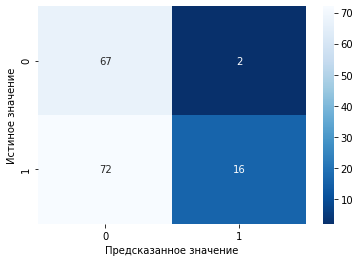

In [93]:
#построение матрицы ошибок
cm = confusion_matrix(y_test, y_pred_3)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues_r')
plt.ylabel('Истиное значение')
plt.xlabel('Предсказанное значение');

При пороге в 0,763 получается следующая картина: две ошибки второго рода, 16 правильных предсказаний "вкусного молока" и 72 ложноотрицательные ошибки. Учитывая, что цель стояла на максимальное уменьшение ошибок первого рода и сохранение адекватности определения классов моделью, то считаем цель достигнутой.

### Прогноз целевого признака на основании полученной модели

Подготовим датасет с коровами, предлагаемыми к продаже по аналогии с основным датасетом и сделаем прогноз целевого признака.

In [94]:
df_buy_log = df_buy.drop(['energy_feed_unit', 'cat_sugar_protein_ratio', 'dad_breed'], axis=1).copy()

In [95]:
df_buy_log = df_buy_log.rename(columns = {'fat_content_current':'fat_content','protein_current':'protein'})

In [96]:
#подготавливаем датасет для прогнозирования
X_buy_ohe = encoder.transform(df_buy_log[cat_col_names])
X_buy_scaled = scaler.transform(df_buy_log[num_col_names])
X_buy_ohe = pd.DataFrame(X_buy_ohe, columns=encoder_col_names)
X_buy_scaled = pd.DataFrame(X_buy_scaled, columns=num_col_names)
X_buy = pd.concat([X_buy_ohe, X_buy_scaled], axis=1)

y_pred_buy = clf.predict(X_buy)

Предсказания получены. Выведем вероятности полчения целевого показателя "вкусное молоко".

In [97]:
y_proba_buy = clf.predict_proba(X_buy)[:,1]

data_buy_res = pd.DataFrame(zip(y_proba_buy),
             columns = ['y_proba_buy']).sort_values(by='y_proba_buy',ascending=False)

print(data_buy_res) 

    y_proba_buy
9      0.815863
13     0.795417
0      0.764708
6      0.764708
16     0.761802
1      0.738759
7      0.718461
2      0.686105
14     0.686105
8      0.686105
19     0.608465
4      0.608465
11     0.578968
15     0.568292
18     0.545055
3      0.474092
10     0.248043
5      0.167537
17     0.151990
12     0.148845


In [98]:
#присваиваем коровам соответствующие классы (порог 0,763)
data_buy_result = []
for i in y_proba_buy:
    if i > 0.763:
        data_buy_result.append(1)
    else:
        data_buy_result.append(0)

**Вывод:** Ранее определили порог отнесения к категории "вкусное молоко" при вероятности 0,763 и более. В соответствии с моделью эту категорию получили 4 коровы из 20.

## Итоговые выводы

1) Выведем таблицу с предлагаемыми коровами с целевыми признаками, которые определили ранее.

In [99]:
df_buy ['yield'] = pd.DataFrame(predictions_yield_buy)
df_buy = df_buy.drop(['energy_feed_unit', 
                      'crude_protein',
                      'sugar_protein_ratio',
                      'cat_sugar_protein_ratio',
                      'sq_energy_feed_unit'], axis=1)

df_buy ['taste'] = pd.DataFrame(data_buy_result)

df_buy

,breed,pasture_type,dad_breed,dad_name,fat_content_current,protein_current,age,yield,taste
0,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,3.58,3.076,более_2_лет,6608.0,1
1,Вис Бик Айдиал,равнинное,Соверин,Буйный,3.54,3.081,менее_2_лет,6334.0,0
2,РефлешнСоверинг,равнинное,Соверин,Барин,3.59,3.074,более_2_лет,6281.0,0
3,РефлешнСоверинг,холмистое,Айдиал,Буйный,3.40,3.061,более_2_лет,6592.0,0
4,РефлешнСоверинг,равнинное,Айдиал,Буйный,3.64,3.074,более_2_лет,6543.0,0
5,РефлешнСоверинг,равнинное,Соверин,Геркулес,3.63,3.053,менее_2_лет,6380.0,0
6,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,3.58,3.076,более_2_лет,6608.0,1
7,Вис Бик Айдиал,равнинное,Соверин,Буйный,3.57,3.079,более_2_лет,6528.0,0
8,РефлешнСоверинг,равнинное,Соверин,Барин,3.59,3.074,более_2_лет,6281.0,0
9,РефлешнСоверинг,холмистое,Айдиал,Буйный,3.40,3.079,менее_2_лет,6398.0,1


2) В части целевого показателя "Удой" все представленные коровы по прогнозу удовлетворяют требования заказчика в 6000 кг/год при условии, что будет соблюдаться условие по качественным характеристикам корма: текущее среднее значение ЭКЕ и СПО плюс 5%. 

3) Однако в части вкусовых качеств согласно логистической модели только коровы прогнозно будут иметь вкусное молоко. Если цель заказчика свести риски получения "невкусного молока" к минимуму, то лучше отказаться от приобретения остальных 16 коров. 

4) Для построения качественной модели линейной регрессии применялись следующие способы: избавление от нерелевантных показателей в модели, добавление новых параметров, избавление от нелинейной зависимости количественных параметров путем классификации и возведения в квадрат. С текущим набором данных улучшить модель линейной регрессии невозможно. Уменьшение параметров приведет к падению точности модели.

5) Основные метрики используемые для анализа модели логистической регрессии - precision и recall. В зависимости от поставленной задачи минимизируются ошибки 1-го рода или 2-го рода для достижения желаемого экономического результата или лучшего порога вероятности отнесения к классам. Также задача может ставится как нахождение такого порога вероятности при котором среднегармоническое значение precision и recall будет максимальным, т.е. общее количество ошибок будет минимально. 